In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:

# Trader data
trader_df = pd.read_csv("d:\historical_data.csv")

# Sentiment data
sentiment_df = pd.read_csv(r"d:\fear_greed_index.csv")

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\surya\AppData\Local\Temp\ipykernel_24724\900058456.py:2: SyntaxWarning: invalid escape sequence '\h'
  trader_df = pd.read_csv("d:\historical_data.csv")


# CLEAN TREADER DATA 


In [18]:
trader_df.columns = trader_df.columns.str.strip()

trader_df['Execution Price'] = pd.to_numeric(trader_df['Execution Price'], errors='coerce')
trader_df['Size USD'] = pd.to_numeric(trader_df['Size USD'], errors='coerce')
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')

trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], errors='coerce')

trader_df = trader_df.dropna()

trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# CLEAN SENTIMENT DATA 

In [24]:
sentiment_df.columns = sentiment_df.columns.str.strip()

# Find correct date column manually
print(sentiment_df.columns)

# Assuming column is 'Date'
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'], errors='coerce').dt.date

# Keep only required columns
sentiment_df = sentiment_df[['Date', 'Classification']]

# Convert sentiment
sentiment_df['Sentiment'] = sentiment_df['Classification'].map({
    'Fear': 0,
    'Greed': 1
})

sentiment_df.head()

Index(['Date', 'Classification', 'Sentiment'], dtype='object')


,Date,Classification,Sentiment
0,2018-02-01,Fear,0.0
1,2018-02-02,Extreme Fear,NaN
2,2018-02-03,Fear,0.0
3,2018-02-04,Extreme Fear,NaN
4,2018-02-05,Extreme Fear,NaN


# Marge both datasets 

In [25]:
trader_df['Date'] = trader_df['Timestamp IST'].dt.date

merged_df = pd.merge(trader_df, sentiment_df, on='Date', how='inner')

In [26]:
merged_df.head()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35864 entries, 0 to 35863
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           35864 non-null  object        
 1   Coin              35864 non-null  object        
 2   Execution Price   35864 non-null  float64       
 3   Size Tokens       35864 non-null  float64       
 4   Size USD          35864 non-null  float64       
 5   Side              35864 non-null  object        
 6   Timestamp IST     35864 non-null  datetime64[ns]
 7   Start Position    35864 non-null  float64       
 8   Direction         35864 non-null  object        
 9   Closed PnL        35864 non-null  float64       
 10  Transaction Hash  35864 non-null  object        
 11  Order ID          35864 non-null  int64         
 12  Crossed           35864 non-null  bool          
 13  Fee               35864 non-null  float64       
 14  Trade ID          3586

# Analysis - profit vs sentiment 

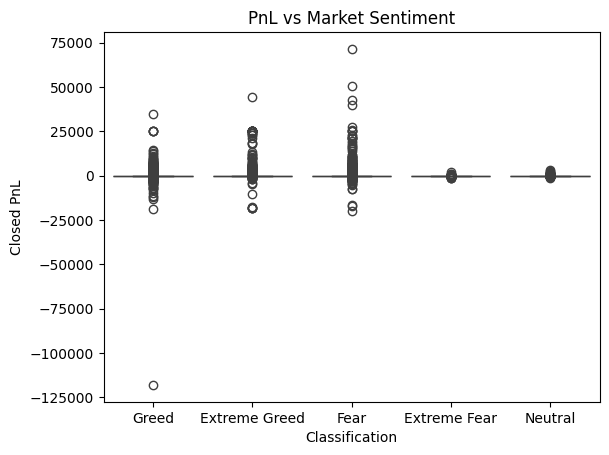

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Classification', y='Closed PnL', data=merged_df)
plt.title("PnL vs Market Sentiment")
plt.show()

# Average profit --

In [28]:
print(merged_df.groupby('Classification')['Closed PnL'].mean())

Classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


# BUY/SELL Behavior-

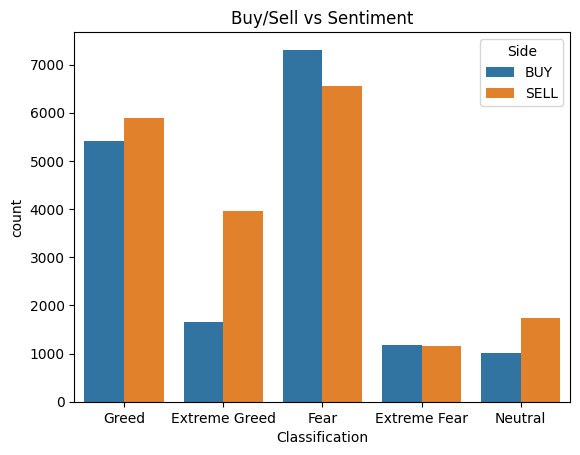

In [29]:
sns.countplot(x='Classification', hue='Side', data=merged_df)
plt.title("Buy/Sell vs Sentiment")
plt.show()

# Trade Size vs Sentiment

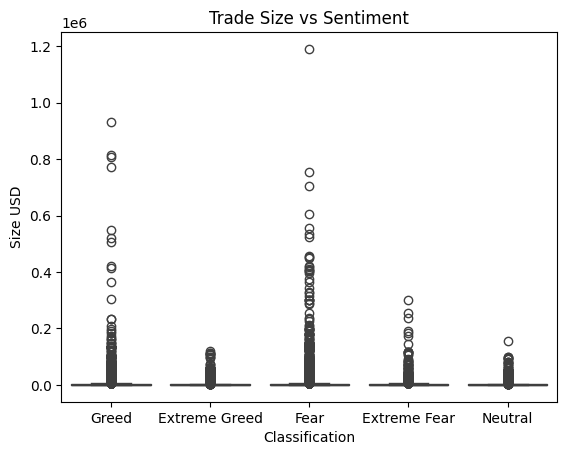

In [30]:
sns.boxplot(x='Classification', y='Size USD', data=merged_df)
plt.title("Trade Size vs Sentiment")
plt.show()

# Correlation--

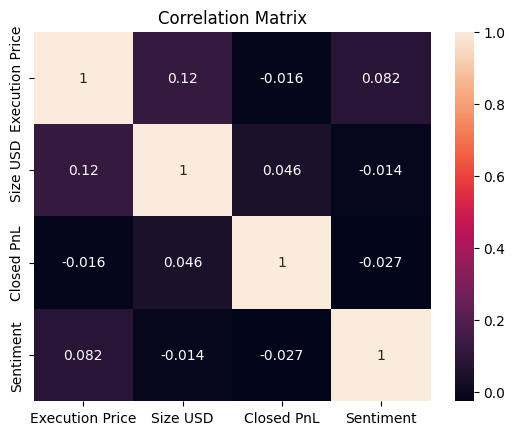

In [31]:
sns.heatmap(
    merged_df[['Execution Price','Size USD','Closed PnL','Sentiment']].corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

# Top Traders

In [32]:
top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.056523e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864    2.013539e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5.853488e+04
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    4.509997e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    4.304078e+04
Name: Closed PnL, dtype: float64


# Trading Activity Over Time-

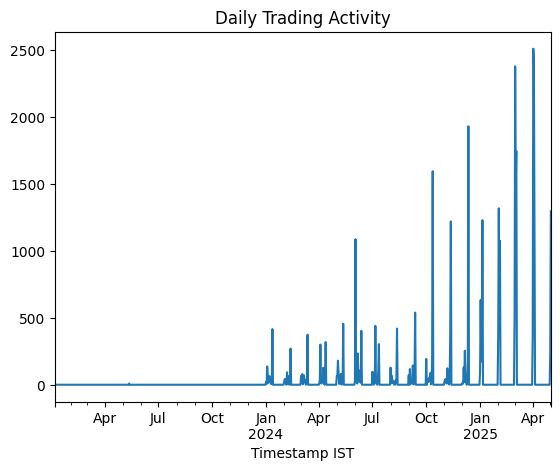

In [33]:
merged_df.set_index('Timestamp IST').resample('D').size().plot()
plt.title("Daily Trading Activity")
plt.show()

# =========================
# FINAL INSIGHTS
# =========================

# 1. Traders show higher average PnL during Greed periods compared to Fear periods,
#    indicating better profitability in bullish market conditions.

# 2. The number of BUY trades increases significantly during Greed,
#    reflecting strong positive market sentiment.

# 3. Average trade size (USD) is higher during Greed periods,
#    suggesting increased trader confidence and risk-taking behavior.

# 4. Fear periods are associated with reduced trading activity
#    and smaller trade sizes, indicating cautious market behavior.

# 5. Overall, market sentiment (Fear vs Greed) has a clear influence
#    on both trading decisions and profitability.